# Fractional Brownian Motion Parameter Estimation Using Periodogram Method

The periodigram method uses the fractional brownian noise power spectrum to estimate the Hurst, denoted by $H$. The power spectrum is the Fourier transform of the fractional brownian motion noise autocorrelation function. This relationship is called the Weiner-Khichnin theorem.</br>

Let $Z^H(t)$ denote a fractional path then fractional brownian noise is defined by,

$
\begin{align}
\Delta Z_k^H = Z^H(t_k) - Z^H(t_{k-1})
\end{align}
\tag{1}
$

where $t_k = k \Delta t$. It follows that,

$
\begin{align}
Z^H(n\Delta t) = \sum_{i=1}^n \Delta Z_k^H
\end{align}
\tag{2}
$

The autocovariance of fractional brownian noise is given by,

$
\begin{align}
\gamma^H_n = \text{Cov}[\Delta Z^H_t \Delta Z^H_{t+n}] = \frac{1}{2}\Delta t^{2H}[(n-1)^{2H} + (n+1)^{2H} - 2n^{2H}]
\end{align}
\tag{3}
$

Since $\text{Var}(\Delta Z_k^H) = \Delta t^{2H}$ the autocorrelation coefficient is defined by,</br>

$
\begin{align}
\rho^H_n = \frac{\gamma^H_n}{\Delta t^{2H}} = \frac{1}{2}[(n-1)^{2H} + (n+1)^{2H} - 2n^{2H}]
\end{align}
\tag{4}
$

From the Weiner-Khichnin theorem the power spectrum is given by,</br>

$
\begin{align}
\hat{\rho}^H_\omega = \frac{1}{2} \int_{-\infty}^{\infty} \rho^H_n e^{-i \omega n} dn
\end{align}
\tag{5}
$

It can be shown that fir $\omega \gg 1$,

$
\begin{align}
\hat{\rho}^H_\omega \approx C\lvert \omega \rvert^{1 - 2H}
\end{align}
\tag{6}
$

where $C$ is independent of $\omega$. It follows that $H$ can be determined by using OLS on $\hat{\rho}^H_\omega$ as a< function of $\omega$.

## Imports

In [33]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../..'))

# import local modules
from lib import config
from lib.data import fbm, stats
from lib.plots import periodogram, curve, PlotType

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [34]:
npts = 2**10

## Power Spectrum Simulation H=0.8

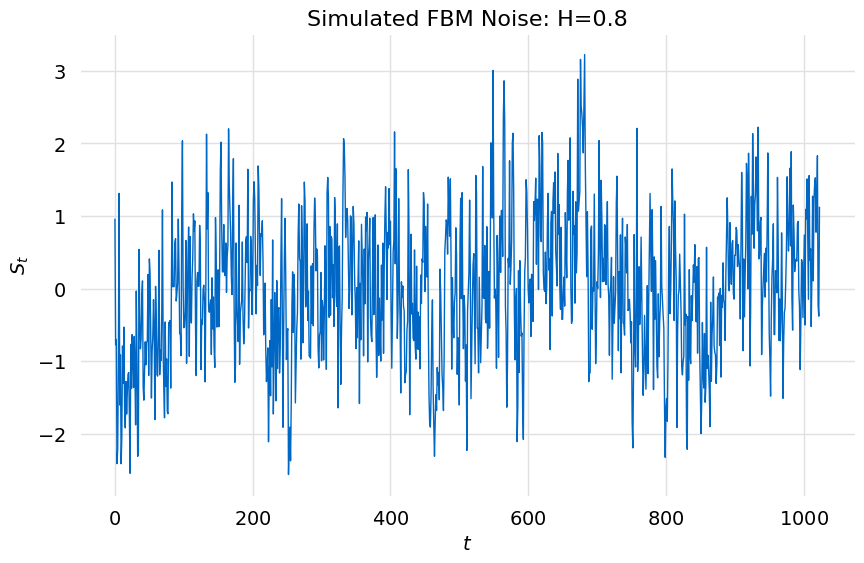

In [48]:
H = 0.8
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

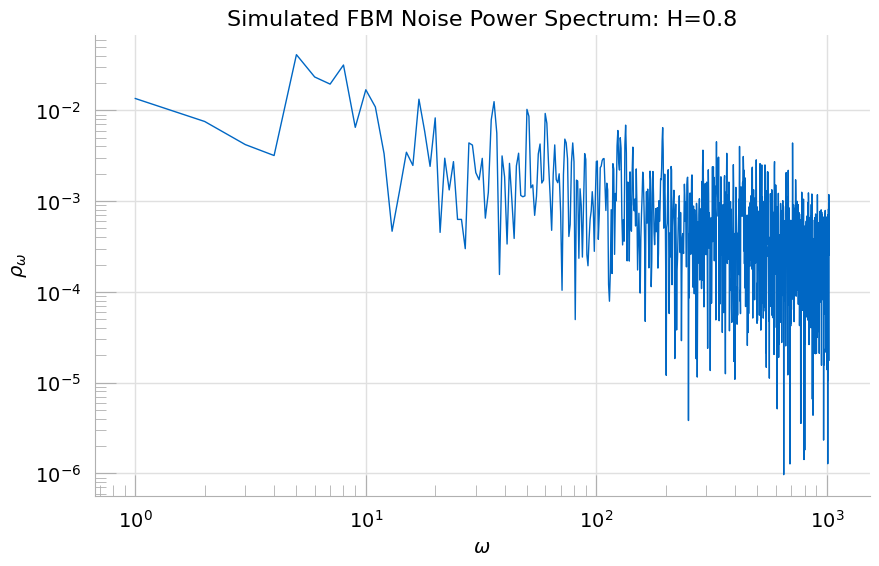

In [49]:
freq, ps = stats.compute_pspec(t, fbm_noise)

title = f"Simulated FBM Noise Power Spectrum: H={H}"
curve(ps, freq, lw=1, title=title, xlabel=r"$\omega$", ylabel=r"$\rho_\omega$", plot_axis_type=PlotType.LOG)

In [51]:
report, results = fbm.compute_H_estimate_periodogram(freq, ps)
report.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.250
Model:                            OLS   Adj. R-squared:                  0.250
Method:                 Least Squares   F-statistic:                     341.1
Date:                Fri, 07 Jul 2023   Prob (F-statistic):           6.12e-66
Time:                        10:53:19   Log-Likelihood:                -822.18
No. Observations:                1023   AIC:                             1648.
Df Residuals:                    1021   BIC:                             1658.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5320      0.103    -14.832      0.000      -1.735      -1.329
x1            -0.7302      0.040    -18.469      0.000      -0.808      -0.653
==============================================================================
Omnibus:                      148.423   Durbin-Watson:                   1.449
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              242.234
Skew:                          -0.948   Prob(JB):                     2.51e-53
Kurtosis:                       4.446   Cond. No.                         18.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [52]:
results.dict

{'est_model': 'OLS_SING_VAR',
 'param': {'Estimate': -0.730177434698109,
  'Error': 0.03953423364517254,
  'Estimate Label': None,
  'Error Label': None},
 'const': {'Estimate': -1.5320461936364984,
  'Error': 0.10329174899728265,
  'Estimate Label': None,
  'Error Label': None},
 'r2': 0.250434437545894,
 'transform': {'model': '$C\\omega^{1 - 2H}$',
  'param': {'Estimate': 0.8650887173490545,
   'Error': 0.01976711682258627,
   'Estimate Label': '$\\hat{Η}$',
   'Error Label': '$\\sigma_{\\hat{Η}}$'},
  'const': {'Estimate': 0.02937337206123041,
   'Error': 0.0030340269741524063,
   'Estimate Label': '$\\hat{C}$',
   'Error Label': '$\\sigma_{\\hat{C}}$'}}}

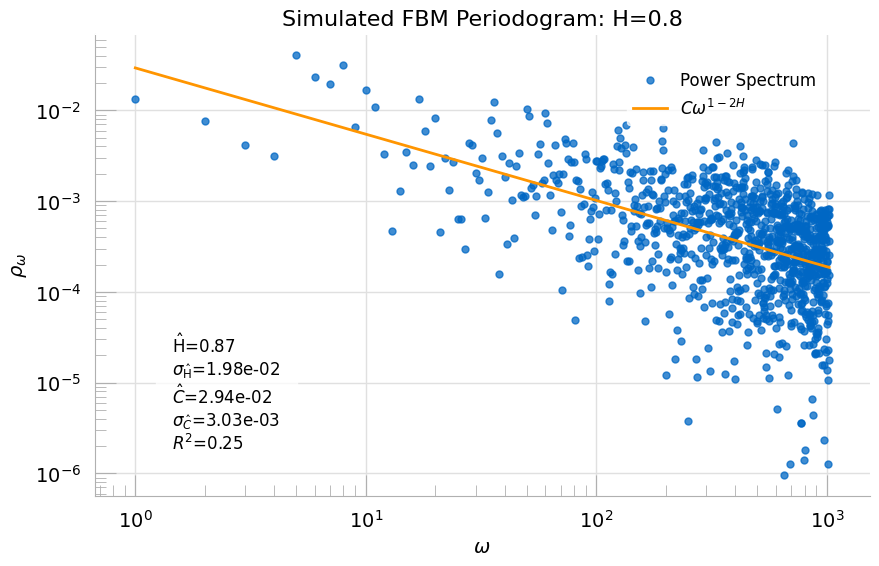

In [53]:
periodogram(ps, results, freq, title=f"Simulated FBM Periodogram: H={H}")

## Power Spectrum Simulation H=0.3

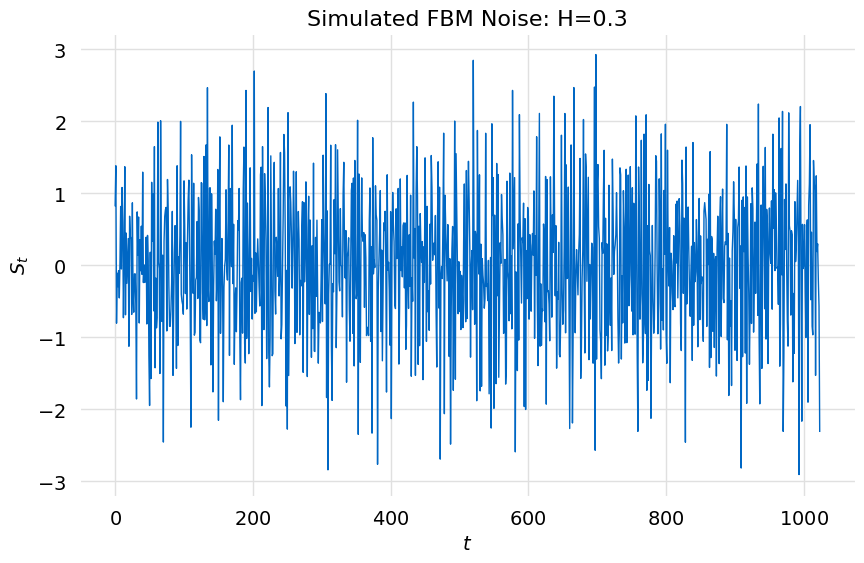

In [40]:
H = 0.3
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

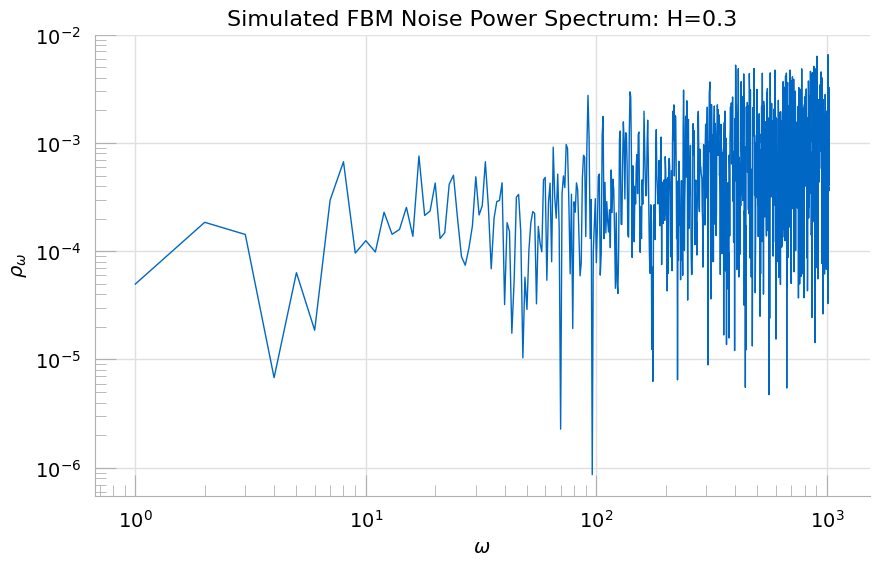

In [41]:
freq, ps = stats.compute_pspec(t, fbm_noise)

title = f"Simulated FBM Noise Power Spectrum: H={H}"
curve(ps, freq, lw=1, title=title, xlabel=r"$\omega$", ylabel=r"$\rho_\omega$", plot_axis_type=PlotType.LOG)

In [42]:
report, results = fbm.compute_H_estimate_periodogram(freq, ps)
report.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     142.6
Date:                Fri, 07 Jul 2023   Prob (F-statistic):           7.37e-31
Time:                        10:51:48   Log-Likelihood:                -810.92
No. Observations:                1023   AIC:                             1626.
Df Residuals:                    1021   BIC:                             1636.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.4902      0.102    -43.952      0.000      -4.691      -4.290
x1             0.4669      0.039     11.941      0.000       0.390       0.544
==============================================================================
Omnibus:                      138.999   Durbin-Watson:                   1.508
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              210.522
Skew:                          -0.937   Prob(JB):                     1.93e-46
Kurtosis:                       4.194   Cond. No.                         18.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [43]:
results.dict

{'est_model': 'OLS_SING_VAR',
 'param': {'Estimate': 0.4669048490987531,
  'Error': 0.03910114679922284,
  'Estimate Label': None,
  'Error Label': None},
 'const': {'Estimate': -4.49016558683501,
  'Error': 0.10216021580032325,
  'Estimate Label': None,
  'Error Label': None},
 'r2': 0.12254036850397876,
 'transform': {'model': '$C\\omega^{1 - 2H}$',
  'param': {'Estimate': 0.26654757545062346,
   'Error': 0.01955057339961142,
   'Estimate Label': '$\\hat{Η}$',
   'Error Label': '$\\sigma_{\\hat{Η}}$'},
  'const': {'Estimate': 3.234703013770346e-05,
   'Error': 3.304579579367345e-06,
   'Estimate Label': '$\\hat{C}$',
   'Error Label': '$\\sigma_{\\hat{C}}$'}}}

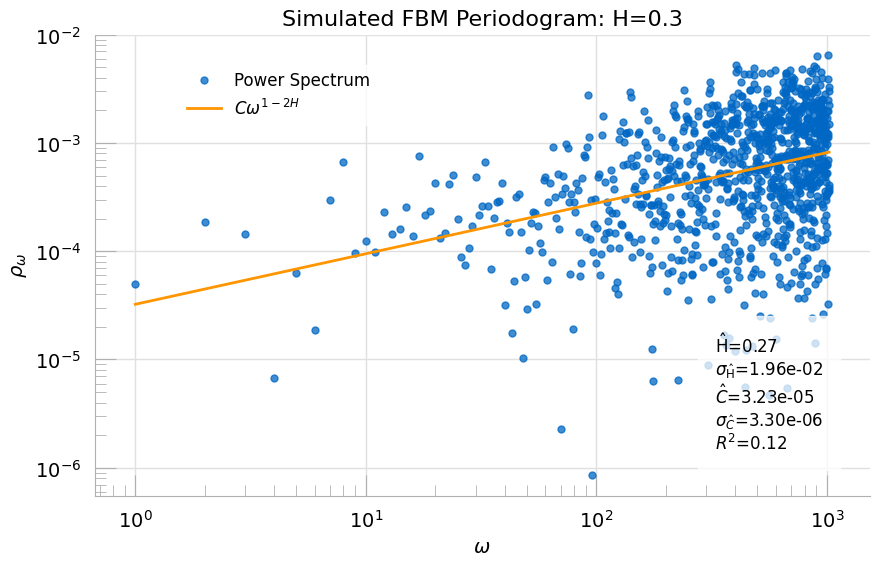

In [47]:
periodogram(ps, results, freq, title=f"Simulated FBM Periodogram: H={H}")